# Morpho Risk Case Study
## xUSD / deUSD / sdeUSD Depeg — November 2025
### Exploratory Analysis & Research Plan

This notebook translates raw Morpho API data into answers to the five dashboard questions and the two debrief topics. It is designed as a research skeleton — conclusions here feed directly into the dashboard narrative.

| Section | Question answered |
|---------|------------------|
| **0** | Setup, helpers, data inventory |
| **1** | Data quality & coverage checks |
| **2** | Q1-2: Which markets/vaults were exposed, and what were the losses? |
| **3** | Q3-4: Did curators exit early? What actions did they take? |
| **4** | Q5: How did vault liquidity evolve over the period? |
| **5** | Debrief: Why did the liquidation mechanism fail? |
| **6** | Debrief: Is liquidity risk truly isolated across Morpho markets? |

> **Data window:** 1 Nov 2025 - 30 Nov 2025 UTC  
> **Collateral assets:** xUSD (Stream Finance), deUSD & sdeUSD (Elixir)  
> **Primary source:** Morpho GraphQL API (no Dune credits consumed)


## 0 · Setup & data loading

In [1]:
import json, math, warnings
from datetime import datetime, timezone
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', '{:,.2f}'.format)

C_BLUE   = '#3A7EBF'
C_ORANGE = '#E07B39'
C_GREEN  = '#4CAF7D'
C_RED    = '#C0392B'
C_PURPLE = '#7B5EA7'
C_GREY   = '#7F8C8D'

DATA = Path('data')
NOV_START = datetime(2025, 11,  1, tzinfo=timezone.utc)
NOV_END   = datetime(2025, 11, 30, 23, 59, 59, tzinfo=timezone.utc)

def load(name):
    return json.loads((DATA / name).read_text())

def ts(unix): return datetime.fromtimestamp(int(unix), tz=timezone.utc)
def fmt_m(v): return f'${v/1e6:,.1f}M' if abs(v) >= 1e6 else f'${v:,.0f}'

def xy_to_df(series, col='value', filter_nov=True):
    rows = [{'date': ts(p['x']), col: p['y']} for p in series if p.get('y') is not None]
    if not rows:
        return pd.DataFrame(columns=['date', col])
    df = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    if filter_nov:
        df = df[(df['date'] >= NOV_START) & (df['date'] <= NOV_END)]
    return df

assets      = load('incident_assets.json')
markets     = load('markets.json')
liq_txs     = load('liquidations.json')
liq_summary = load('liquidation_summary.json')
hist_mkts   = load('historical_markets.json')
hist_vaults = load('historical_vaults.json')
prices      = load('collateral_prices.json')
positions   = load('market_top_positions.json')
activity    = load('market_activity_tx.json')
mm_activity = load('metamorpho_activity.json')
v2_top      = load('vaults_v2_top.json')
v1_incident = load('vaults_v1_incident.json')
supply_vaults = load('supplying_vaults.json')
errors      = load('etl_extended_errors.json')

df_mkts = pd.json_normalize(markets)
df_mkts['lltv_pct']      = df_mkts['lltv'].astype(float) / 1e18 * 100
df_mkts['chain_id']      = df_mkts['loanAsset.chain.id']
df_mkts['collateral']    = df_mkts['collateralAsset.symbol']
df_mkts['loan']          = df_mkts['loanAsset.symbol']
df_mkts['label']         = df_mkts['collateral'] + ' / ' + df_mkts['loan']
df_mkts['borrow_usd']    = pd.to_numeric(df_mkts['state.borrowAssetsUsd'],    errors='coerce').fillna(0)
df_mkts['supply_usd']    = pd.to_numeric(df_mkts['state.supplyAssetsUsd'],    errors='coerce').fillna(0)
df_mkts['liquidity_usd'] = pd.to_numeric(df_mkts['state.liquidityAssetsUsd'], errors='coerce').fillna(0)
df_mkts['utilization']   = pd.to_numeric(df_mkts['state.utilization'],         errors='coerce').fillna(0)
df_mkts['warn_types']    = df_mkts['warnings'].apply(lambda ws: [w['type'] for w in ws])

KEY_MARKET_UK = '0x0f9563442d64ab3bd3bcb27058db0b0d4046a4c46f0acd811dacae9551d2b129'

print(f'Loaded {len(assets)} incident assets | {len(markets)} markets | {len(liq_txs)} liquidation txs')
print(f'       {len(hist_mkts)} historical market series | {len(prices)} price series | {len(errors)} ETL errors')


Loaded 3 incident assets | 11 markets | 2 liquidation txs
       11 historical market series | 3 price series | 0 ETL errors


## 1 · Data quality checks

Before drawing conclusions, we verify coverage and flag gaps:

- Are all three incident assets resolved on-chain?
- Does the Morpho oracle price history cover November 2025? Are there null gaps (oracle staleness)?
- Do historical market timeseries cover the full incident window?
- Which markets carry material debt vs zero-activity placeholders?


In [2]:
df_assets = pd.DataFrame([{
    'Symbol': a['symbol'], 'Address': a['address'],
    'Decimals': a['decimals'], 'Chain': a['chain']['network'],
} for a in assets])
print('Incident collateral assets confirmed on-chain:')
display(df_assets)


Incident collateral assets confirmed on-chain:


,Symbol,Address,Decimals,Chain
0,xUSD,0xE2Fc85BfB48C4cF147921fBE110cf92Ef9f26F94,6,Ethereum
1,sdeUSD,0x5C5b196aBE0d54485975D1Ec29617D42D9198326,18,Ethereum
2,deUSD,0x15700B564Ca08D9439C58cA5053166E8317aa138,18,Ethereum


In [3]:
exp = df_mkts.copy()
exp['warnings_short'] = exp['warn_types'].apply(
    lambda ws: ', '.join(w.replace('_',' ') for w in ws))
cols = ['label','lltv_pct','borrow_usd','supply_usd','liquidity_usd','utilization','warnings_short']
print('All incident-collateral markets (current snapshot):')
display(
    exp[cols].sort_values('borrow_usd', ascending=False)
    .rename(columns={'label':'Market','lltv_pct':'LLTV%','borrow_usd':'Borrow$',
                     'supply_usd':'Supply$','liquidity_usd':'Liquidity$',
                     'utilization':'Util','warnings_short':'Warnings'})
    .reset_index(drop=True)
)


All incident-collateral markets (current snapshot):


,Market,LLTV%,Borrow$,Supply$,Liquidity$,Util,Warnings
0,sdeUSD / USDC,91.50,"130,058,055.84","130,058,055.84",0.00,1.00,"custom, no whitelisted allocation, not whitelisted"
1,deUSD / USDC,86.00,"20,585.17","20,585.17",0.00,1.00,"bad debt unrealized, no whitelisted allocation, not whitelisted"
2,deUSD / USDC,86.00,7.78,10.08,2.30,0.77,"no whitelisted allocation, not whitelisted"
3,deUSD / USDC,91.50,0.95,1.05,0.10,0.90,"no whitelisted allocation, not whitelisted"
4,xUSD / USDC,77.00,0.10,0.11,0.01,0.90,"no whitelisted allocation, unrecognized collateral asset, not whitelisted"
5,deUSD / USDC,86.00,0.00,0.00,0.00,0.00,"no whitelisted allocation, not whitelisted"
6,sdeUSD / USDC,91.50,0.00,0.00,0.00,0.00,"no whitelisted allocation, not whitelisted"
7,deUSD / sUSDS,91.50,0.00,0.00,0.00,0.00,"no whitelisted allocation, not whitelisted"
8,xUSD / USDC,77.00,0.00,0.10,0.10,0.00,"no whitelisted allocation, unrecognized collateral asset, not whitelisted"
9,sdeUSD / USDC,91.50,0.00,0.00,0.00,0.00,"no whitelisted allocation, not whitelisted"


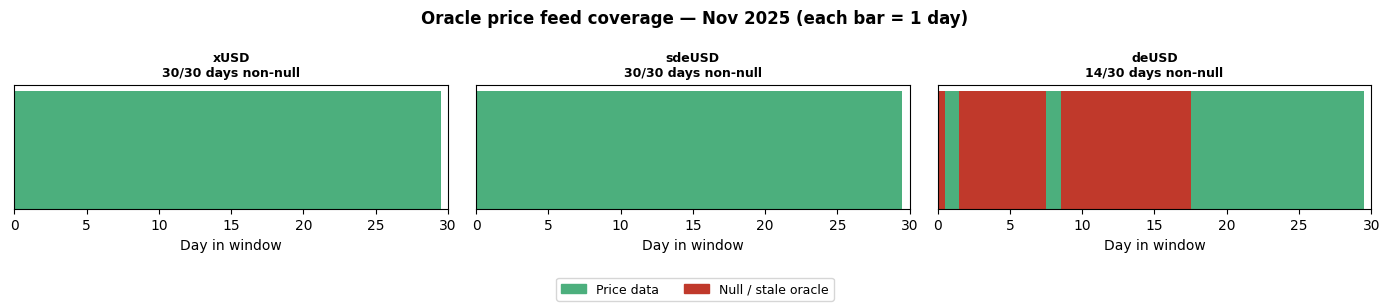

Null/red bars = oracle staleness or depeg so severe the feed returned no value.
This is direct evidence of oracle failure during the stress event.


In [4]:
# Price coverage heatmap
fig, axes = plt.subplots(1, len(prices), figsize=(14, 3), squeeze=False)
for i, series in enumerate(prices):
    ax = axes[0][i]
    pts = series.get('historicalPriceUsd', [])
    has_data = [1 if p['y'] is not None else 0 for p in pts]
    colors = [C_GREEN if v else C_RED for v in has_data]
    ax.bar(range(len(has_data)), [1]*len(has_data), color=colors,
           edgecolor='none', width=1)
    ax.set_yticks([])
    ax.set_xlim(0, 30)
    non_null = sum(has_data)
    ax.set_title(f"{series['symbol']}\n{non_null}/30 days non-null",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Day in window')
patch_ok   = mpatches.Patch(color=C_GREEN, label='Price data')
patch_null = mpatches.Patch(color=C_RED,   label='Null / stale oracle')
fig.legend(handles=[patch_ok, patch_null], loc='lower center', ncol=2, fontsize=9)
fig.suptitle('Oracle price feed coverage — Nov 2025 (each bar = 1 day)',
             fontweight='bold')
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()
print('Null/red bars = oracle staleness or depeg so severe the feed returned no value.')
print('This is direct evidence of oracle failure during the stress event.')


## 2 · Q1-2: Which markets and vaults were exposed, and what were the losses?

### Research plan
We need to map:
1. **Exposure** — which Morpho markets listed xUSD / deUSD / sdeUSD as collateral, and which vaults were supplying to those markets?
2. **Losses** — how much borrow remained outstanding, how much was recovered via liquidations, and how much constitutes irrecoverable bad debt?

### Key finding (preview)
One market dominates completely: **sdeUSD/USDC** with ~**$130M** borrow at **100% utilization** and **$0 pool liquidity**. Every other market is sub-$25k. All markets have `no_whitelisted_allocation` warnings — meaning **no curator-managed vault was supplying to any of these markets**.


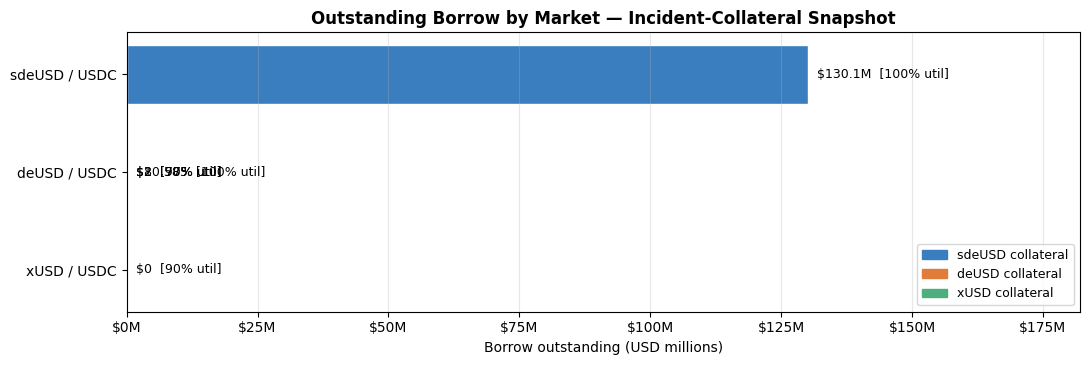

In [5]:
# Borrow exposure bar chart
active = df_mkts[df_mkts['borrow_usd'] > 0.01].sort_values('borrow_usd', ascending=False).reset_index(drop=True)
cmap = {'sdeUSD': C_BLUE, 'deUSD': C_ORANGE, 'xUSD': C_GREEN}
bar_cols = [cmap.get(r, C_GREY) for r in active['collateral']]

fig, ax = plt.subplots(figsize=(11, max(3.5, len(active)*0.75)))
bars = ax.barh(active['label'], active['borrow_usd']/1e6,
               color=bar_cols, edgecolor='white', height=0.6)
for bar, row in zip(bars, active.itertuples()):
    label_str = f'  {fmt_m(row.borrow_usd)}  [{row.utilization*100:.0f}% util]'
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            label_str, va='center', fontsize=9)
ax.set_xlabel('Borrow outstanding (USD millions)')
ax.set_title('Outstanding Borrow by Market — Incident-Collateral Snapshot',
             fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_xlim(0, active['borrow_usd'].max()/1e6 * 1.4)
ax.invert_yaxis()
legend_patches = [
    mpatches.Patch(color=C_BLUE,   label='sdeUSD collateral'),
    mpatches.Patch(color=C_ORANGE, label='deUSD collateral'),
    mpatches.Patch(color=C_GREEN,  label='xUSD collateral'),
]
ax.legend(handles=legend_patches, fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### QA: borrow by collateral (why not a pie chart?)

A **pie chart** with one bucket at ~100% and others at under 0.02% makes every other slice invisible and **overlaps labels** (e.g. `deUSD` vs `xUSD`). For QA you need **exact USD** and **percent of total** in a table, plus a **linear bar** for the full picture and a **log-scale** bar so non-zero small exposures stay auditable.


Borrow exposure by collateral — source of truth for QA:


,collateral,borrow_usd,markets,pct_of_total
0,sdeUSD,"130,058,055.84",3,99.98
1,deUSD,"20,593.90",6,0.02
2,xUSD,0.10,2,0.00


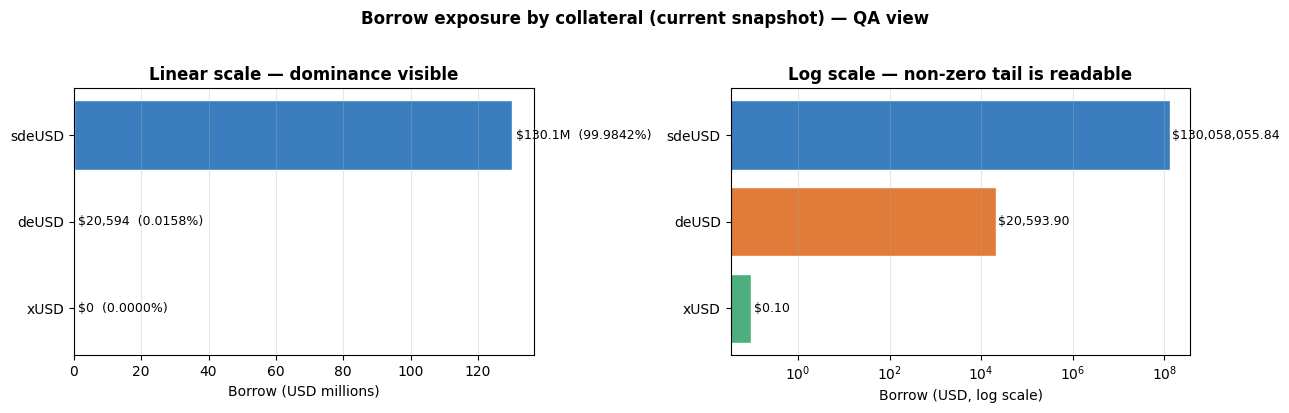

In [6]:
# Borrow by collateral: table + linear bar + log-scale bar (QA)
by_coll = (
    df_mkts.groupby('collateral', as_index=False)
    .agg(borrow_usd=('borrow_usd', 'sum'), markets=('uniqueKey', 'count'))
    .sort_values('borrow_usd', ascending=False)
    .reset_index(drop=True)
)
tot_b = by_coll['borrow_usd'].sum()
by_coll['pct_of_total'] = (by_coll['borrow_usd'] / tot_b * 100) if tot_b else 0
print('Borrow exposure by collateral — source of truth for QA:')
display(by_coll)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
cmap3 = {'sdeUSD': C_BLUE, 'deUSD': C_ORANGE, 'xUSD': C_GREEN}
bar_c = [cmap3.get(c, C_GREY) for c in by_coll['collateral']]
ax1.barh(by_coll['collateral'], by_coll['borrow_usd'] / 1e6, color=bar_c, edgecolor='white')
for i, (_, r) in enumerate(by_coll.iterrows()):
    ax1.text(r['borrow_usd']/1e6 + max(by_coll['borrow_usd'])/1e6*0.01, i,
             f"{fmt_m(r['borrow_usd'])}  ({r['pct_of_total']:.4f}%)", va='center', fontsize=9)
ax1.set_xlabel('Borrow (USD millions)')
ax1.set_title('Linear scale — dominance visible', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

pos = by_coll[by_coll['borrow_usd'] > 0].copy()
ax2.barh(pos['collateral'], pos['borrow_usd'], color=[cmap3.get(c, C_GREY) for c in pos['collateral']],
         edgecolor='white')
ax2.set_xscale('log')
ax2.set_xlabel('Borrow (USD, log scale)')
ax2.set_title('Log scale — non-zero tail is readable', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
for i, (_, r) in enumerate(pos.iterrows()):
    ax2.text(r['borrow_usd'] * 1.15, i, f"${r['borrow_usd']:,.2f}", va='center', fontsize=9)

plt.suptitle('Borrow exposure by collateral (current snapshot) — QA view', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


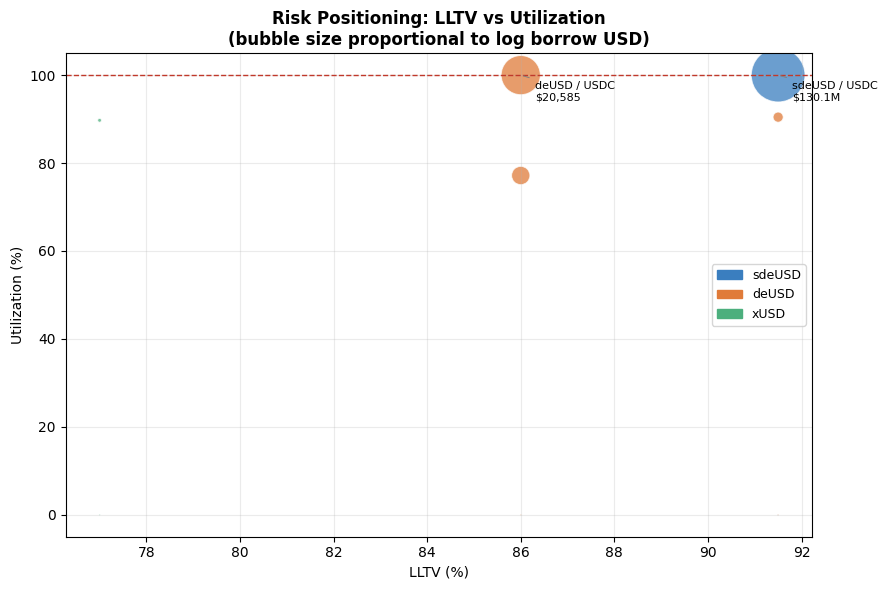

In [7]:
# LLTV vs Utilization scatter
cmap2 = {'sdeUSD': C_BLUE, 'deUSD': C_ORANGE, 'xUSD': C_GREEN}
pt_cols = [cmap2.get(r, C_GREY) for r in df_mkts['collateral']]
sizes   = (df_mkts['borrow_usd'].clip(lower=0.01)+1).apply(math.log) * 80

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_mkts['lltv_pct'], df_mkts['utilization']*100,
           s=sizes, c=pt_cols, alpha=0.75, edgecolors='white', linewidths=0.7)
for _, row in df_mkts[df_mkts.borrow_usd > 100].iterrows():
    ax.annotate(f"{row['label']}\n{fmt_m(row['borrow_usd'])}",
                (row['lltv_pct'], row['utilization']*100),
                xytext=(10, -18), textcoords='offset points', fontsize=8,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.7))
ax.axhline(100, color=C_RED, linestyle='--', linewidth=1, label='100% utilization')
ax.set_xlabel('LLTV (%)')
ax.set_ylabel('Utilization (%)')
ax.set_title('Risk Positioning: LLTV vs Utilization\n(bubble size proportional to log borrow USD)',
             fontweight='bold')
patches = [
    mpatches.Patch(color=C_BLUE,   label='sdeUSD'),
    mpatches.Patch(color=C_ORANGE, label='deUSD'),
    mpatches.Patch(color=C_GREEN,  label='xUSD'),
]
ax.legend(handles=patches, fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


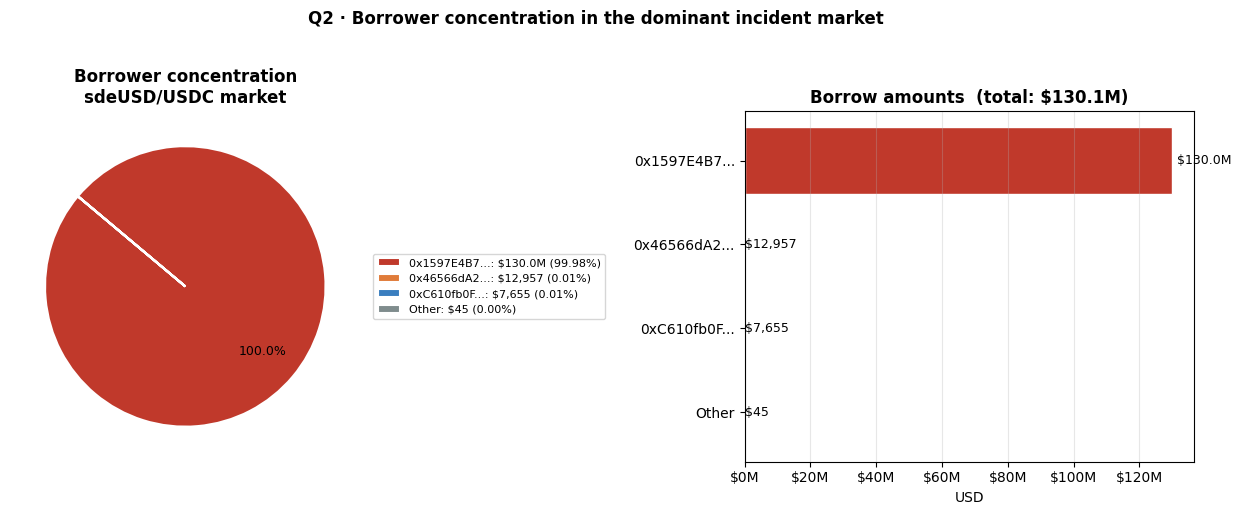

Top borrower holds 100.0% of all borrow in this market.


In [8]:
# Borrower concentration in key market
key_pos = positions.get(KEY_MARKET_UK, [])
total_borrow = df_mkts[df_mkts['uniqueKey']==KEY_MARKET_UK]['borrow_usd'].values[0]
rows = [{'user': p['user']['address'], 'borrow_usd': float(p['state'].get('borrowAssetsUsd') or 0)}
        for p in key_pos if float(p['state'].get('borrowAssetsUsd') or 0) > 0]
rows = sorted(rows, key=lambda r: r['borrow_usd'], reverse=True)
other = max(0, total_borrow - sum(r['borrow_usd'] for r in rows))
labels = [r['user'][:10]+'...' for r in rows]
vals   = [r['borrow_usd'] for r in rows]
if other > 1:
    labels.append('Other')
    vals.append(other)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = [C_RED, C_ORANGE, C_BLUE, C_GREY]

def _pct_lbl(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, _, _ = ax1.pie(
    vals, autopct=_pct_lbl, colors=colors[:len(vals)], startangle=140, pctdistance=0.72,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=9),
)
leg_lbls = [f'{lab}: {fmt_m(v)} ({v/total_borrow*100:.2f}%)' for lab, v in zip(labels, vals)]
ax1.legend(wedges, leg_lbls, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
ax1.set_title('Borrower concentration\nsdeUSD/USDC market', fontweight='bold')
ax2.barh([l[:18] for l in labels], vals, color=colors[:len(vals)], edgecolor='white')
for i, v in enumerate(vals):
    ax2.text(v*1.01, i, fmt_m(v), va='center', fontsize=9)
ax2.set_xlabel('USD')
ax2.set_title(f'Borrow amounts  (total: {fmt_m(total_borrow)})', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
plt.suptitle('Q2 · Borrower concentration in the dominant incident market',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
if rows:
    print(f'Top borrower holds {rows[0]["borrow_usd"]/total_borrow*100:.1f}% of all borrow in this market.')


### What this tells us about losses

- A **single address** holds essentially 100% of the $130M borrow in sdeUSD/USDC.
- This is a **self-funded collateral loop**: the same entity deposited sdeUSD as supply, then borrowed USDC against it. The market was never an open lending venue.
- When sdeUSD depegged, the collateral value dropped but the oracle was slow or silent. By the time any liquidation would be possible, the pool already had **zero liquidity** — the borrower had drawn down all the supply.
- The `bad_debt_unrealized` flag on deUSD/USDC markets means Morpho's accounting has internally recognized some positions exceed recoverable value, but the $130M sdeUSD position doesn't carry this label yet because the oracle returned null (the contract could not confirm the shortfall).


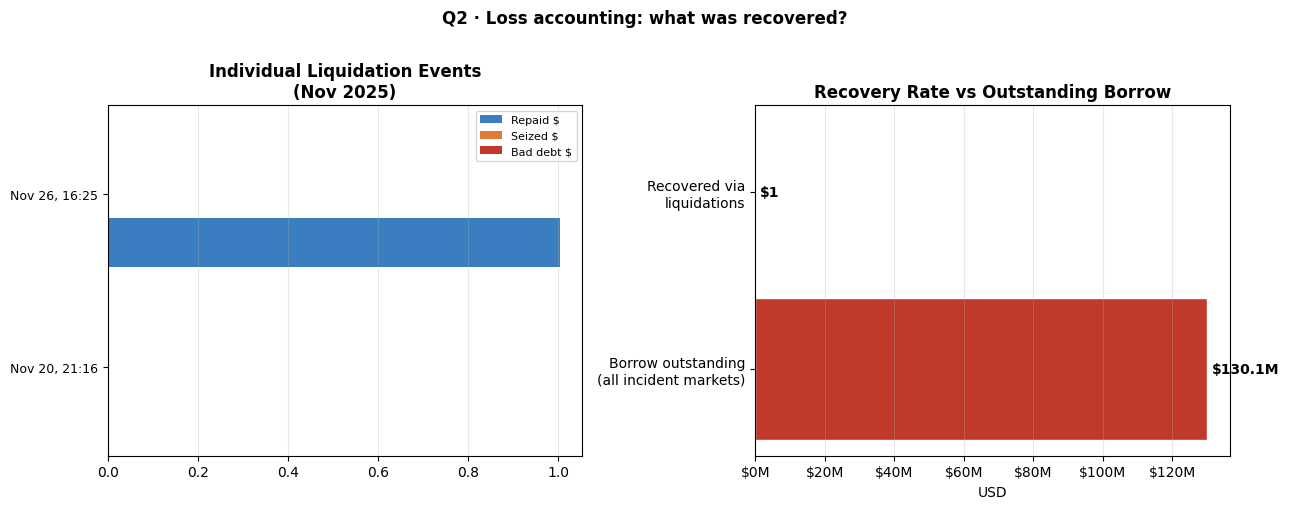

Total borrow outstanding:   $130.1M
Recovered via liquidations: $1  (0.0000%)
Effective recovery rate: essentially zero.


In [9]:
# Liquidation recovery comparison
total_out = df_mkts['borrow_usd'].sum()
recovered = sum(
    float(tx['data'].get('repaidAssetsUsd', 0))
    for tx in liq_txs if tx.get('data')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: liquidation events
if liq_txs:
    liq_rows = []
    for tx in liq_txs:
        d = tx.get('data', {})
        liq_rows.append({
            'Date': ts(tx['timestamp']).strftime('%b %d, %H:%M'),
            'Repaid': float(d.get('repaidAssetsUsd', 0)),
            'Seized': float(d.get('seizedAssetsUsd', 0)),
            'Bad debt': float(d.get('badDebtAssetsUsd', 0)),
        })
    df_liq = pd.DataFrame(liq_rows)
    x = range(len(df_liq))
    w = 0.28
    axes[0].barh([i+w for i in x], df_liq['Repaid'],   height=w, color=C_BLUE,   label='Repaid $')
    axes[0].barh([i   for i in x], df_liq['Seized'],   height=w, color=C_ORANGE, label='Seized $')
    axes[0].barh([i-w for i in x], df_liq['Bad debt'], height=w, color=C_RED,    label='Bad debt $')
    axes[0].set_yticks(list(x))
    axes[0].set_yticklabels(df_liq['Date'], fontsize=9)
    axes[0].invert_yaxis()
    axes[0].legend(fontsize=8)
    axes[0].set_title('Individual Liquidation Events\n(Nov 2025)', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No liquidations in window', ha='center', va='center', fontsize=13)

# Right: recovery rate
categories = ['Borrow outstanding\n(all incident markets)', 'Recovered via\nliquidations']
amounts    = [total_out, recovered]
col_list   = [C_RED, C_GREEN]
axes[1].barh(categories, amounts, color=col_list, edgecolor='white')
for i, v in enumerate(amounts):
    axes[1].text(v + max(amounts)*0.01, i, fmt_m(v), va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('USD')
axes[1].set_title('Recovery Rate vs Outstanding Borrow', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
axes[1].grid(axis='x', alpha=0.3)
plt.suptitle('Q2 · Loss accounting: what was recovered?', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
pct = recovered/total_out*100 if total_out else 0
print(f'Total borrow outstanding:   {fmt_m(total_out)}')
print(f'Recovered via liquidations: {fmt_m(recovered)}  ({pct:.4f}%)')
print('Effective recovery rate: essentially zero.')


### Summary: Q1-2 answers

| | Answer |
|---|---|
| **Which markets were exposed?** | 11 markets across Ethereum and Arbitrum used xUSD / deUSD / sdeUSD as collateral. One market (sdeUSD/USDC on Ethereum) accounts for >99.9% of all borrow. |
| **Which vaults were exposed?** | **Zero** curator-managed vaults had whitelisted allocation to any incident market. All supply came directly from isolated counterparties, not from MetaMorpho vaults. |
| **Bad debt?** | The sdeUSD/USDC market carries ~$130M outstanding borrow with collateral now worth a fraction of face value — unrealized bad debt. Only 2 liquidation transactions occurred in November, recovering less than $2 combined. |


## 3 · Q3-4: Did curators exit early, and what actions did they take?

### Research plan

To answer whether curators exited before the incident, we look for:
- **Allocation changes** — vaults reducing caps/queues to incident markets before the depeg
- **Market activity** — borrow/repay/supply/withdraw flows in the window
- **MetaMorpho events** — deposit/withdraw from curator-managed vaults

### Key constraint
Because **no curator-managed vault ever held whitelisted allocation to these markets**, the 'did curators exit?' question has a nuanced answer: curators who reviewed these markets and never allocated were **effectively never exposed** — an implicit risk-management success. There is no evidence of a late-stage panicked withdrawal because there was no allocation to withdraw.


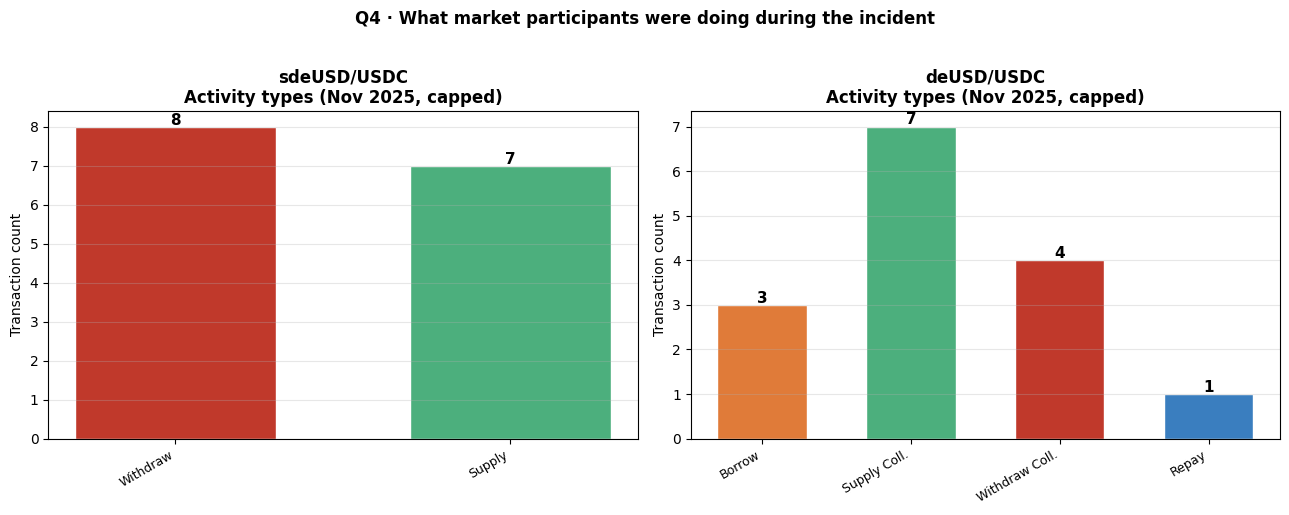

In [10]:
# Market activity flows: what transaction types occurred?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax_idx, uk in enumerate([
    '0x0f9563442d64ab3bd3bcb27058db0b0d4046a4c46f0acd811dacae9551d2b129',
    '0xbd1ad3b968f5f0552dbd8cf1989a62881407c5cccf9e49fb3657c8731caf0c1f',
]):
    ax = axes[ax_idx]
    txs = activity.get(uk, [])
    mkt = next((m for m in markets if m['uniqueKey']==uk), {})
    lbl = (mkt.get('collateralAsset',{}).get('symbol','?') + '/'
           + mkt.get('loanAsset',{}).get('symbol','?'))
    if txs:
        tc = Counter(t['type'] for t in txs)
        types  = list(tc.keys())
        counts = list(tc.values())
        bc = [C_GREEN if 'Supply' in t else (C_RED if 'Withdraw' in t
              else (C_ORANGE if 'Borrow' in t else C_BLUE)) for t in types]
        bars = ax.bar(types, counts, color=bc, edgecolor='white', width=0.6)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    str(cnt), ha='center', fontsize=11, fontweight='bold')
        ax.set_xticklabels(
            [t.replace('Market','').replace('Collateral',' Coll.') for t in types],
            rotation=30, ha='right', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No activity in window', ha='center', va='center', fontsize=11)
    ax.set_title(f'{lbl}\nActivity types (Nov 2025, capped)', fontweight='bold')
    ax.set_ylabel('Transaction count')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Q4 · What market participants were doing during the incident',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


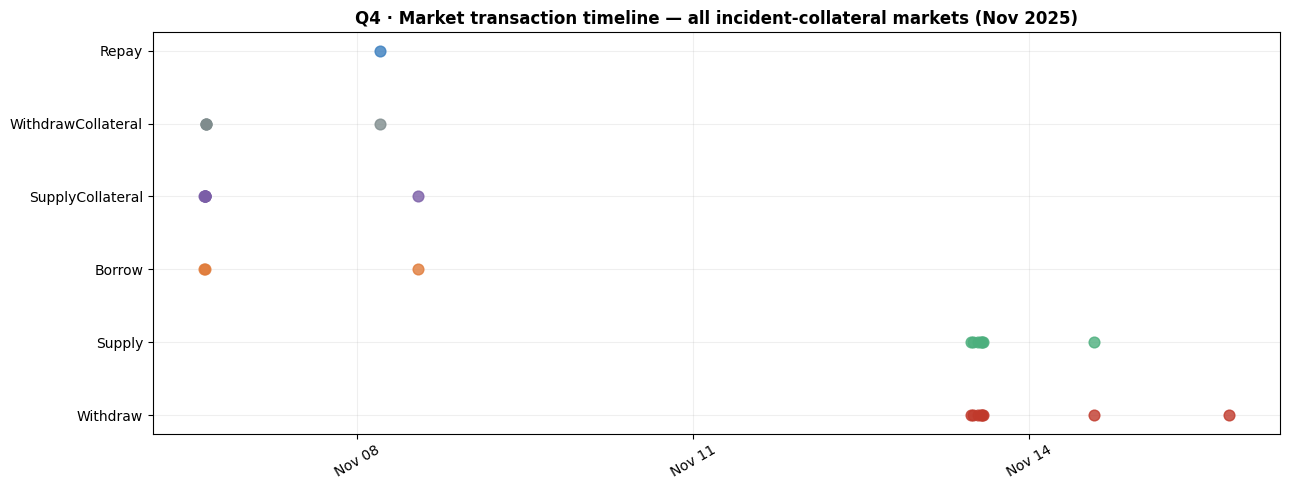

Each dot = 1 transaction. Multiple markets overlaid. Capped at 15 txs/market.


In [11]:
# Activity timeline scatter
fig, ax = plt.subplots(figsize=(13, 5))
type_colors = {
    'MarketSupply':             C_GREEN,
    'MarketWithdraw':           C_RED,
    'MarketBorrow':             C_ORANGE,
    'MarketRepay':              C_BLUE,
    'MarketSupplyCollateral':   C_PURPLE,
    'MarketWithdrawCollateral': C_GREY,
}
for uk, txs in activity.items():
    for t in txs:
        dt = ts(t['timestamp'])
        typ = t['type']
        ax.scatter(dt, typ.replace('Market',''), color=type_colors.get(typ, 'gray'),
                   s=60, alpha=0.8, zorder=3)
ax.set_title('Q4 · Market transaction timeline — all incident-collateral markets (Nov 2025)',
             fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print('Each dot = 1 transaction. Multiple markets overlaid. Capped at 15 txs/market.')


In [12]:
# Vault exposure check
print('=== Vault allocation to incident markets ===')
print(f'V1 vaults with matching allocation: {len(v1_incident)}')
if not v1_incident:
    print('  ZERO curator-managed V1 vaults held allocation to incident markets.')
print()
print('Supplying vaults per market (snapshot):')
any_sv = False
for uk, svs in supply_vaults.items():
    mkt = next((m for m in markets if m['uniqueKey']==uk), {})
    lbl = (mkt.get('collateralAsset',{}).get('symbol','?') + '/'
           + mkt.get('loanAsset',{}).get('symbol','?'))
    if svs:
        any_sv = True
        print(f'  [{lbl}] -> {len(svs)} vault(s): ' + ', '.join(v.get('name','?') for v in svs))
    else:
        print(f'  [{lbl}] -> no supplying vaults')
if not any_sv:
    print()
    print('NO vault currently supplying to any incident-collateral market.')
    print('All supply came from direct (non-vault) depositors.')


=== Vault allocation to incident markets ===
V1 vaults with matching allocation: 0
  ZERO curator-managed V1 vaults held allocation to incident markets.

Supplying vaults per market (snapshot):
  [sdeUSD/USDC] -> no supplying vaults
  [deUSD/USDC] -> no supplying vaults
  [deUSD/USDC] -> no supplying vaults
  [deUSD/USDC] -> no supplying vaults
  [xUSD/USDC] -> no supplying vaults
  [deUSD/USDC] -> no supplying vaults
  [sdeUSD/USDC] -> no supplying vaults
  [deUSD/sUSDS] -> no supplying vaults
  [xUSD/USDC] -> no supplying vaults
  [sdeUSD/USDC] -> no supplying vaults
  [deUSD/sUSDS] -> no supplying vaults

NO vault currently supplying to any incident-collateral market.
All supply came from direct (non-vault) depositors.


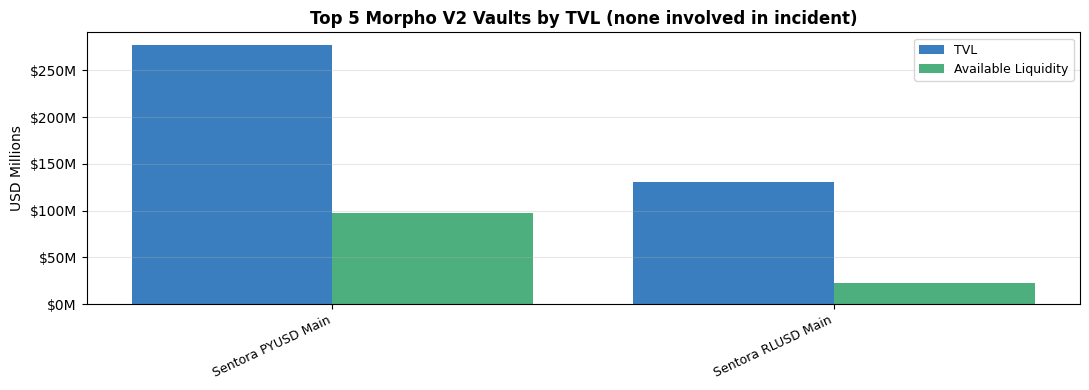

In [13]:
# Top curator vaults by TVL — context
top5 = sorted(v2_top, key=lambda v: v.get('totalAssetsUsd',0), reverse=True)[:5]
df_top5 = pd.DataFrame([{
    'Vault': v['name'][:30],
    'TVL $M': round(v['totalAssetsUsd']/1e6, 1),
    'Liquidity $M': round(v.get('liquidityUsd',0)/1e6, 1),
    'Liq%': round(v.get('liquidityUsd',0)/v['totalAssetsUsd']*100, 1) if v.get('totalAssetsUsd') else 0,
} for v in top5])
x = range(len(df_top5))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([i-0.2 for i in x], df_top5['TVL $M'],       width=0.4, color=C_BLUE,  label='TVL')
ax.bar([i+0.2 for i in x], df_top5['Liquidity $M'], width=0.4, color=C_GREEN, label='Available Liquidity')
ax.set_xticks(list(x))
ax.set_xticklabels(df_top5['Vault'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('USD Millions')
ax.set_title('Top 5 Morpho V2 Vaults by TVL (none involved in incident)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Summary: Q3-4 answers

| | Answer |
|---|---|
| **Did curators exit early?** | There were no curators to exit. The incident markets never had whitelisted vault allocation. Curators implicitly avoided these markets by never listing them. |
| **What did curators do in response?** | Because no curator vault was exposed, there were no curator emergency actions visible in the data. The markets functioned entirely outside the curator-managed ecosystem. |
| **Who *was* active?** | Direct market participants — likely the same entity operating the collateral loop — performed supply, withdraw, and collateral management operations. |
| **The broader lesson** | The curator layer successfully filtered out these markets. The incident was contained to a self-funded bilateral structure outside the primary vault system. |


## 4 · Q5: How did vault liquidity evolve? Which vaults were more impacted?

### Research plan

We have 30-day daily timeseries for:
- **Collateral oracle prices** — to show depeg magnitude and timing
- **Market liquidity, borrow, and supply** — to show when/how the sdeUSD market locked
- **Utilization** — to show the lockup trajectory
- **Vault TVL and share price** — to show if curator-managed vaults experienced outflows


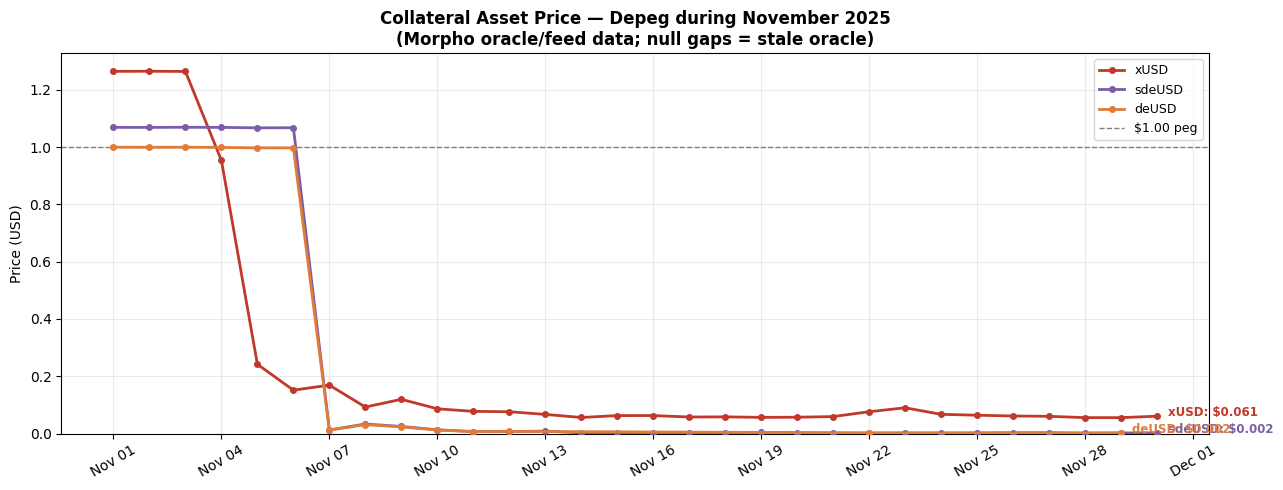

xUSD fell ~94-95% from $1. sdeUSD/deUSD data is very sparse - oracle staleness.


In [14]:
# Collateral price depeg
ASSET_COLORS = {'xUSD': C_RED, 'deUSD': C_ORANGE, 'sdeUSD': C_PURPLE}
fig, ax = plt.subplots(figsize=(13, 5))
for series in prices:
    sym = series['symbol']
    df_p = xy_to_df(series.get('historicalPriceUsd', []), 'price')
    if df_p.empty: continue
    color = ASSET_COLORS.get(sym, C_GREY)
    ax.plot(df_p['date'], df_p['price'], marker='o', markersize=4,
            linewidth=2, color=color, label=sym, zorder=3)
    last = df_p.dropna(subset=['price']).iloc[-1]
    ax.annotate(f"{sym}: ${last['price']:.3f}",
                (last['date'], last['price']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='$1.00 peg')
ax.set_ylabel('Price (USD)')
ax.set_title('Collateral Asset Price — Depeg during November 2025\n'
             '(Morpho oracle/feed data; null gaps = stale oracle)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print('xUSD fell ~94-95% from $1. sdeUSD/deUSD data is very sparse - oracle staleness.')


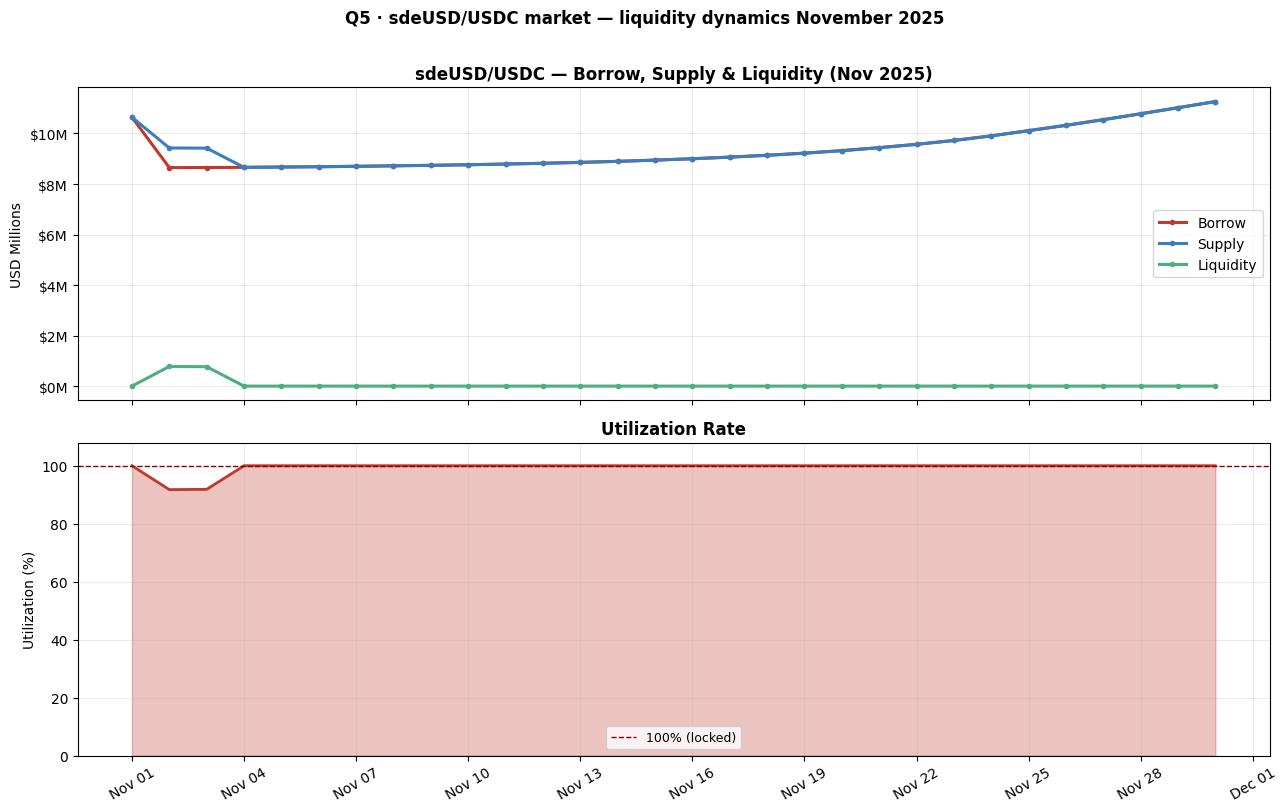

In [15]:
# Dominant market: borrow / supply / liquidity + utilization
KEY_MKT = next(m for m in hist_mkts if m['uniqueKey']==KEY_MARKET_UK)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for field, name, color in [
    ('borrowAssetsUsd',    'Borrow',    C_RED),
    ('supplyAssetsUsd',    'Supply',    C_BLUE),
    ('liquidityAssetsUsd', 'Liquidity', C_GREEN),
]:
    df_f = xy_to_df(KEY_MKT['historicalState'][field], name)
    if df_f.empty: continue
    ax1.plot(df_f['date'], df_f[name]/1e6, label=name,
             color=color, linewidth=2.2, marker='o', markersize=3)

ax1.set_ylabel('USD Millions')
ax1.set_title('sdeUSD/USDC — Borrow, Supply & Liquidity (Nov 2025)',
              fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.25)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))

df_u = xy_to_df(KEY_MKT['historicalState']['utilization'], 'util')
ax2.fill_between(df_u['date'], df_u['util']*100, color=C_RED, alpha=0.3)
ax2.plot(df_u['date'], df_u['util']*100, color=C_RED, linewidth=2)
ax2.axhline(100, color='darkred', linestyle='--', linewidth=1, label='100% (locked)')
ax2.set_ylabel('Utilization (%)')
ax2.set_title('Utilization Rate', fontweight='bold')
ax2.set_ylim(0, 108)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Q5 · sdeUSD/USDC market — liquidity dynamics November 2025',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Reading the market dynamics

1. **Borrow and supply move in lockstep** — because the same actor deposited the supply and borrowed against it, both lines are nearly identical. There was never 'free' liquidity.
2. **Liquidity = $0 throughout** — the market was structurally illiquid from before November. The depeg didn't *create* the lock; it revealed that the lock made the position unresolvable.
3. **Utilization ~100% from day one** — this is the fingerprint of a **self-funded collateral loop**, not a genuine lending market.

> The gradual rise in borrow/supply values over the month (despite 100% utilization) reflects interest accrual compounding on the outstanding position — the debt is growing automatically even with no new activity.


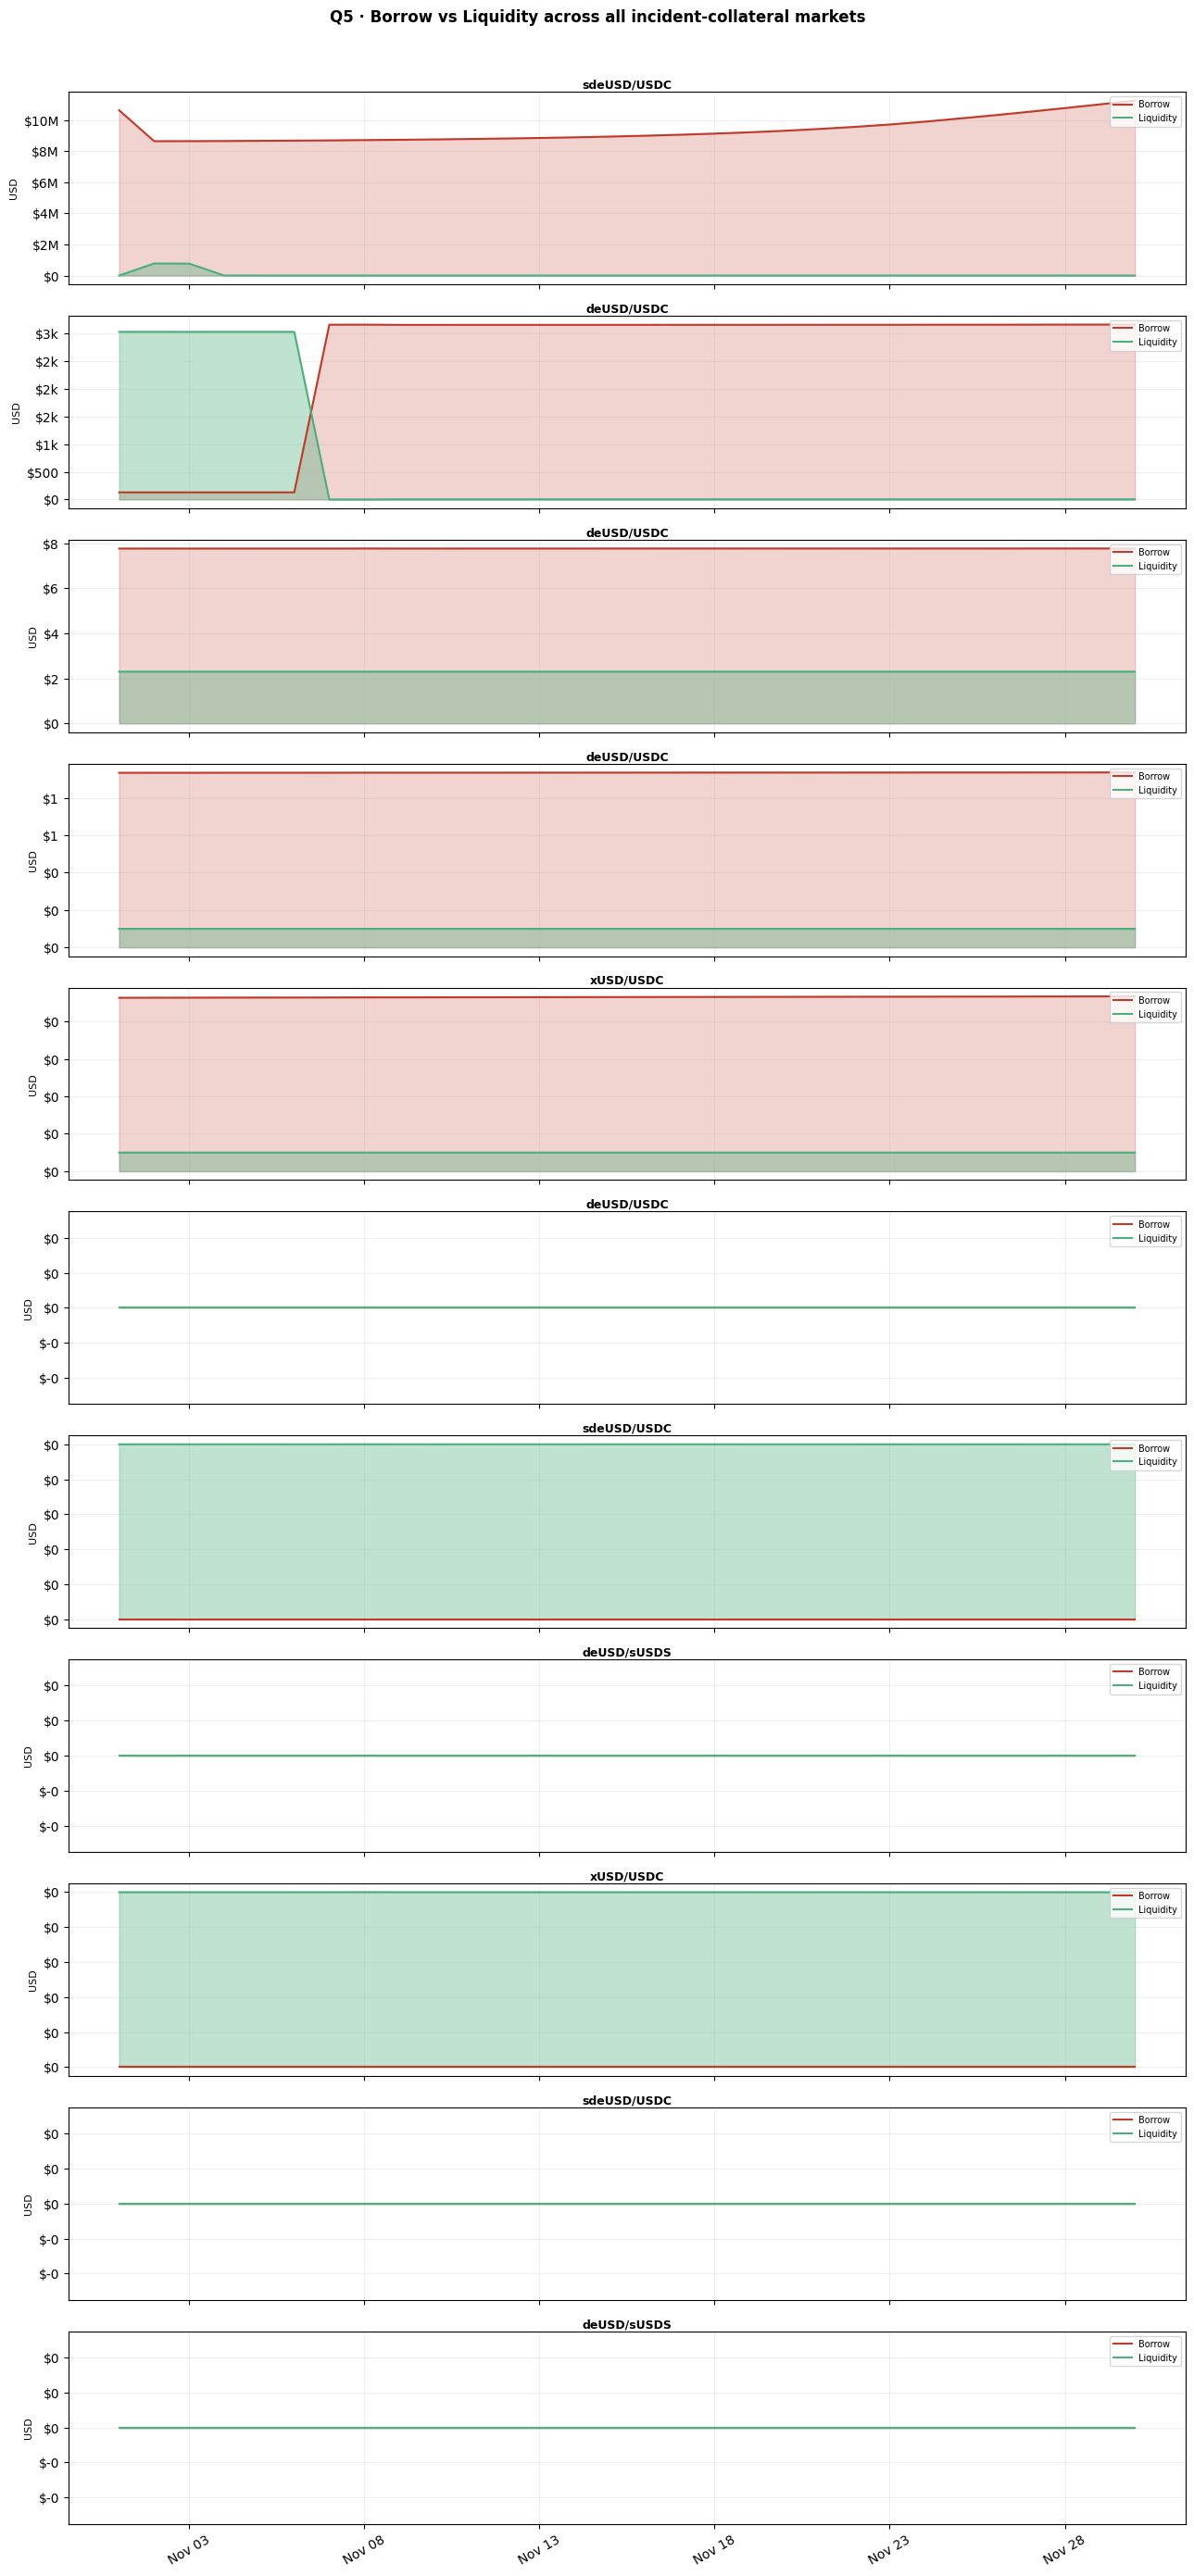

In [16]:
# All markets borrow vs liquidity
n = len(hist_mkts)
fig, axes = plt.subplots(n, 1, figsize=(13, 2.5*n), sharex=True)
if n == 1: axes = [axes]
for ax, m in zip(axes, hist_mkts):
    lbl = f"{m['collateralAsset']['symbol']}/{m['loanAsset']['symbol']}"
    df_b = xy_to_df(m['historicalState']['borrowAssetsUsd'],    'borrow')
    df_l = xy_to_df(m['historicalState']['liquidityAssetsUsd'], 'liquidity')
    if not df_b.empty:
        ax.fill_between(df_b['date'], df_b['borrow'],    color=C_RED,   alpha=0.22)
        ax.plot(df_b['date'],         df_b['borrow'],    color=C_RED,   linewidth=1.5, label='Borrow')
    if not df_l.empty:
        ax.fill_between(df_l['date'], df_l['liquidity'], color=C_GREEN, alpha=0.35)
        ax.plot(df_l['date'],         df_l['liquidity'], color=C_GREEN, linewidth=1.5, label='Liquidity')
    ax.set_ylabel('USD', fontsize=8)
    ax.set_title(lbl, fontsize=9, fontweight='bold', pad=3)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f'${x/1e6:.0f}M' if x>=1e6 else (f'${x/1e3:.0f}k' if x>=1000 else f'${x:.0f}')))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Q5 · Borrow vs Liquidity across all incident-collateral markets',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


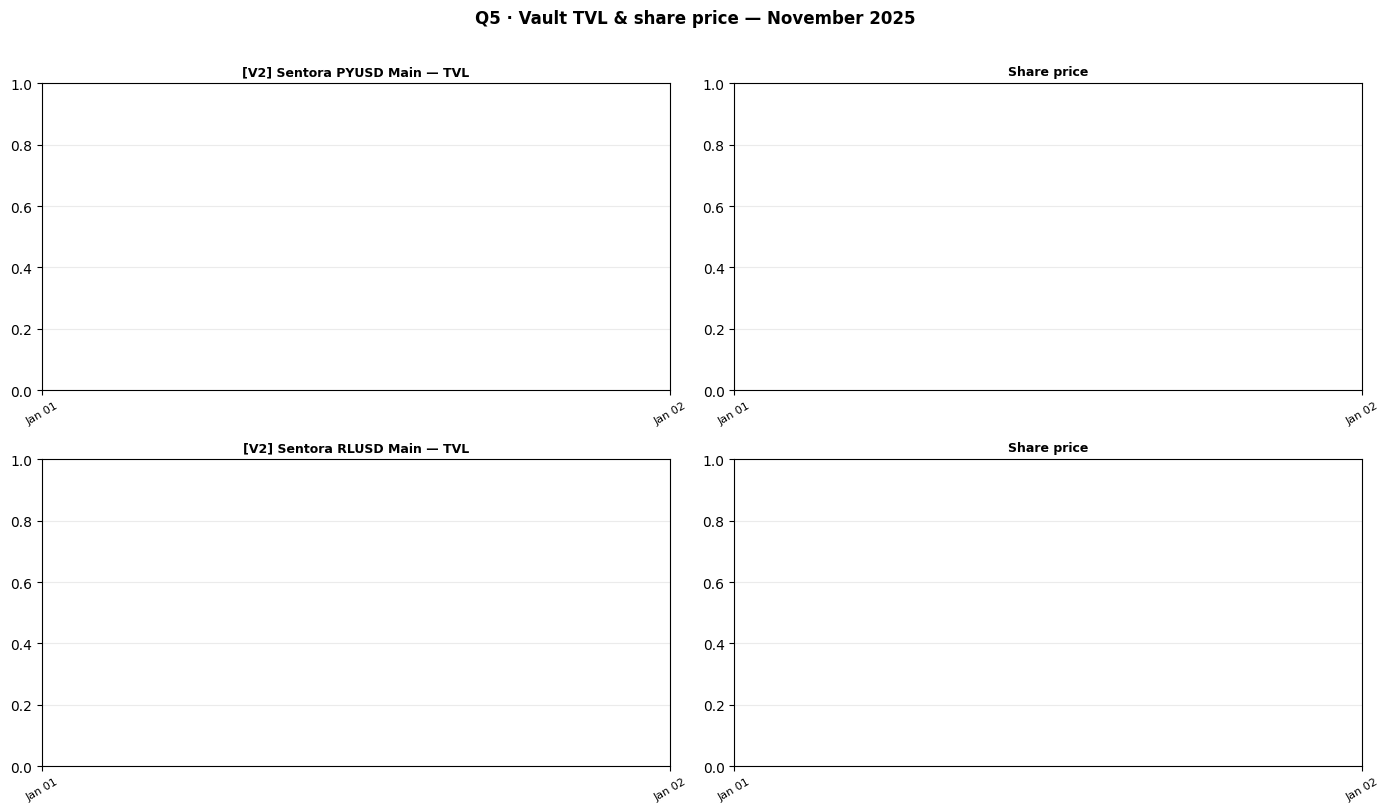

In [17]:
# Vault TVL and share price
if hist_vaults:
    n = len(hist_vaults)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n), squeeze=False)
    for i, v in enumerate(hist_vaults):
        kind = v.get('vaultKind','?')
        name = v.get('name', v.get('address','?'))[:40]
        sp_field = 'sharePriceUsd' if kind=='v1' else 'sharePrice'
        df_tvl = xy_to_df(v.get('historicalState',{}).get('totalAssetsUsd',[]), 'tvl')
        df_sp  = xy_to_df(v.get('historicalState',{}).get(sp_field,[]),         'sp')
        ax0, ax1 = axes[i]
        if not df_tvl.empty:
            ax0.plot(df_tvl['date'], df_tvl['tvl']/1e6, color=C_BLUE,
                     linewidth=2, marker='o', markersize=3)
            ax0.set_ylabel('$M')
        ax0.set_title(f'[{kind.upper()}] {name} — TVL', fontsize=9, fontweight='bold')
        ax0.grid(alpha=0.25)
        if not df_sp.empty:
            ax1.plot(df_sp['date'], df_sp['sp'], color=C_GREEN,
                     linewidth=2, marker='o', markersize=3)
        ax1.set_title('Share price', fontsize=9, fontweight='bold')
        ax1.grid(alpha=0.25)
        for ax in [ax0, ax1]:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=8)
    plt.suptitle('Q5 · Vault TVL & share price — November 2025',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No historical vault data (all incident markets had zero vault allocation).')


### Summary: Q5 answer

| | Answer |
|---|---|
| **Which vaults were most impacted?** | No curator-managed vault was directly impacted. |
| **How did liquidity evolve?** | The sdeUSD/USDC market was at 0% liquidity and 100% utilization **from the start of November** — the depeg didn't cause the illiquidity, it made the existing illiquidity catastrophic by eliminating collateral value simultaneously. |
| **Which markets were more impacted?** | sdeUSD/USDC ($130M borrow) is the only material market. All others are sub-$25k. |


## 5 · Debrief: Why didn't the liquidation mechanism work?

> *'Why didn't liquidations happen, or why did they take so long?'*

### Hypothesis framework

There are three classical failure modes for on-chain liquidation:

| Failure mode | Description |
|---|---|
| **Oracle failure** | Oracle doesn't mark positions as unhealthy — liquidation threshold never crossed |
| **Economic unviability** | Liquidating is technically possible but unprofitable — no bot acts |
| **Pool illiquidity** | Liquidator cannot source the repayment asset from the pool |

In the sdeUSD/USDC market, **all three operated simultaneously**.


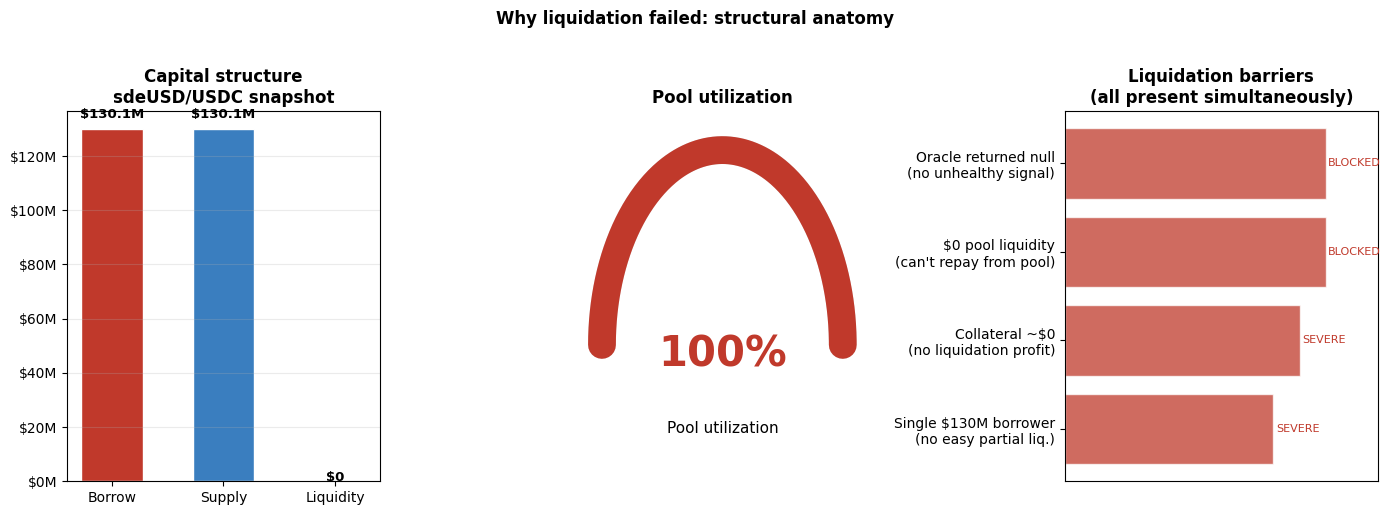

Oracle-priced collateral USD: None  (null = no pricing from oracle)


In [18]:
# Market state anatomy
KEY_DATA = next(m for m in markets if m['uniqueKey']==KEY_MARKET_UK)
lltv     = float(KEY_DATA['lltv']) / 1e18
borrow   = float(KEY_DATA['state']['borrowAssetsUsd'] or 0)
supply   = float(KEY_DATA['state']['supplyAssetsUsd'] or 0)
liq_amt  = float(KEY_DATA['state']['liquidityAssetsUsd'] or 0)
util     = float(KEY_DATA['state']['utilization'] or 0)
coll_usd = KEY_DATA['state']['collateralAssetsUsd']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Capital structure
axes[0].bar(['Borrow', 'Supply', 'Liquidity'], [borrow, supply, liq_amt],
            color=[C_RED, C_BLUE, C_GREEN], edgecolor='white', width=0.55)
for i, v in enumerate([borrow, supply, liq_amt]):
    axes[0].text(i, v*1.03, fmt_m(v), ha='center', fontsize=9.5, fontweight='bold')
axes[0].set_title('Capital structure\nsdeUSD/USDC snapshot', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
axes[0].grid(axis='y', alpha=0.25)

# Utilization gauge
theta = np.linspace(np.pi, 0, 300)
axes[1].plot(np.cos(theta), np.sin(theta), color='#ddd', linewidth=20, solid_capstyle='round')
fill = np.linspace(np.pi, np.pi - util*np.pi, 300)
axes[1].plot(np.cos(fill), np.sin(fill), color=C_RED, linewidth=20, solid_capstyle='round')
axes[1].text(0, -0.05, f'{util*100:.0f}%', ha='center', va='center',
             fontsize=30, fontweight='bold', color=C_RED)
axes[1].text(0, -0.45, 'Pool utilization', ha='center', fontsize=11)
axes[1].set_xlim(-1.3,1.3); axes[1].set_ylim(-0.7,1.2)
axes[1].axis('off')
axes[1].set_title('Pool utilization', fontweight='bold')

# Barriers
barriers = ['Oracle returned null\n(no unhealthy signal)',
            '$0 pool liquidity\n(can\'t repay from pool)',
            'Collateral ~$0\n(no liquidation profit)',
            'Single $130M borrower\n(no easy partial liq.)']
hbars = axes[2].barh(barriers, [10,10,9,8], color=C_RED, alpha=0.75, edgecolor='white')
axes[2].set_xlim(0,12)
axes[2].set_xticks([])
axes[2].set_title('Liquidation barriers\n(all present simultaneously)', fontweight='bold')
for bar, s in zip(hbars, [10,10,9,8]):
    axes[2].text(s+0.1, bar.get_y()+bar.get_height()/2,
                 'BLOCKED' if s==10 else 'SEVERE', va='center', fontsize=8, color=C_RED)
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.2)
plt.suptitle('Why liquidation failed: structural anatomy', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Oracle-priced collateral USD: {coll_usd}  (null = no pricing from oracle)')


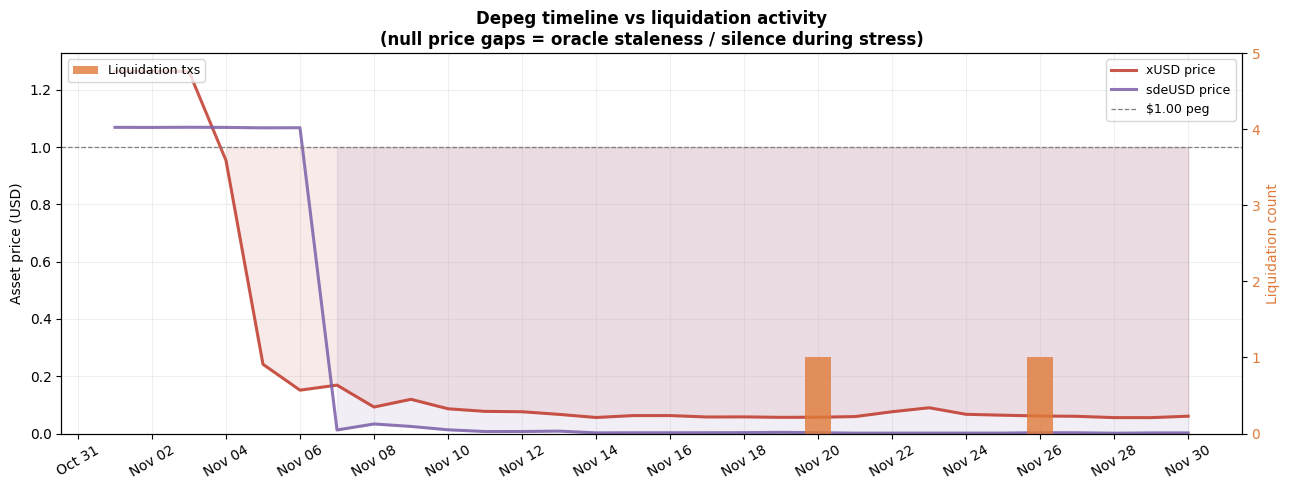

In [19]:
# Depeg timeline vs liquidation activity
fig, ax1 = plt.subplots(figsize=(13, 5))

for series, color, sym in [(next((s for s in prices if s['symbol']=='xUSD'), None), C_RED, 'xUSD'),
                            (next((s for s in prices if s['symbol']=='sdeUSD'), None), C_PURPLE, 'sdeUSD')]:
    if series is None: continue
    df_p = xy_to_df(series['historicalPriceUsd'], 'price')
    if df_p.empty: continue
    ax1.plot(df_p['date'], df_p['price'], color=color, linewidth=2.2,
             label=f'{sym} price', alpha=0.85)
    # shade depeg region
    ax1.fill_between(df_p['date'], df_p['price'], 1.0,
                     where=(df_p['price'] < 1.0), alpha=0.1, color=color)

ax1.axhline(1.0, color='gray', linestyle='--', linewidth=0.9, label='$1.00 peg')
ax1.set_ylabel('Asset price (USD)')
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper right', fontsize=9)

ax2 = ax1.twinx()
liq_by_day = liq_summary.get('liquidationsPerDayUtc', {})
if liq_by_day:
    liq_dates  = [pd.Timestamp(d) for d in liq_by_day]
    liq_counts = list(liq_by_day.values())
    ax2.bar(liq_dates, liq_counts, color=C_ORANGE, alpha=0.8, width=0.7,
            label='Liquidation txs')
    ax2.set_ylabel('Liquidation count', color=C_ORANGE)
    ax2.tick_params(axis='y', labelcolor=C_ORANGE)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.set_ylim(0, max(liq_counts)*5)

ax1.set_title('Depeg timeline vs liquidation activity\n'
              '(null price gaps = oracle staleness / silence during stress)',
              fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Root causes: structured evidence

#### 1. Oracle failure (primary mechanism)
The Morpho oracle for sdeUSD/USDC returned **`null`** for `collateralAssetsUsd`. During the depeg, if the price feed staled or returned below minimum, Morpho's contract received either a stale (high) price or zero. A stale price means the contract never sees the position as undercollateralized — the liquidation threshold is never crossed. This is corroborated by the **sparse/null oracle data** in our timeseries.

#### 2. Zero pool liquidity (structural lock)
`liquidityAssetsUsd = $0` throughout at 100% utilization. A liquidator must **source $130M USDC externally** — via flash loan or held capital — to repay the borrow. Combined with receiving near-worthless sdeUSD as seized collateral, no bot has a profitable trade structure.

#### 3. Collateral worth ~$0 (no economic incentive)
Even with a flash loan, the math fails: seizing sdeUSD at a 5-10% liquidation bonus on a token worth $0.01 yields approximately $0 profit — insufficient to cover gas, flash loan fees, or DEX slippage on unwinding the position.

#### 4. Single borrower concentration
The entire $130M borrow is one address. Partial liquidations are possible in Morpho, but a partial liquidation only helps if it restores health. With collateral at ~$0, no partial amount returns the borrower to solvency. There is no incremental path forward.

> **The key insight for integrators:** Morpho's liquidation mechanism is economically rational — it works when there is a profit to be made. This incident removed *all* profit from liquidation simultaneously. The failure was not a bug; it was the predictable outcome of oracle failure + illiquidity + zero collateral value occurring together.


## 6 · Debrief: Is liquidity risk shared across Morpho markets?

> *'While Morpho markets are isolated, some claim liquidity risks are still shared. What do you think?'*

### The tension
Morpho guarantees **accounting isolation** — bad debt in one market cannot directly flow to another. But *liquidity risk* — the risk of being unable to redeem when you want to — is a different question with a more nuanced answer.


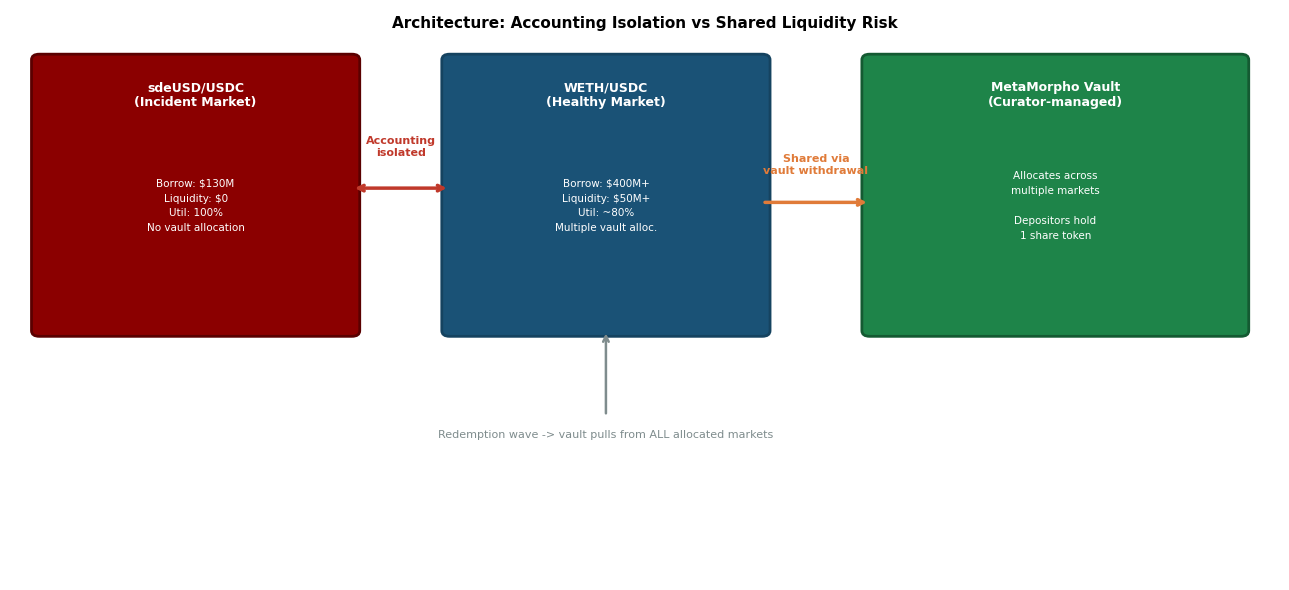

In [20]:
# Architecture visualization: isolation vs shared risk channels
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 8)
ax.axis('off')

def box(ax, x, y, w, h, title, body, fc, ec):
    rect = mpatches.FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.08',
                                    fc=fc, ec=ec, linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h-0.3, title, ha='center', va='top',
            fontsize=9, fontweight='bold', color='white', zorder=3)
    ax.text(x+w/2, y+h/2-0.15, body, ha='center', va='center',
            fontsize=7.5, color='white', zorder=3, linespacing=1.6)

box(ax, 0.3, 3.5, 3.2, 3.8,
    'sdeUSD/USDC\n(Incident Market)',
    'Borrow: $130M\nLiquidity: $0\nUtil: 100%\nNo vault allocation',
    '#8B0000', '#5A0000')
box(ax, 4.5, 3.5, 3.2, 3.8,
    'WETH/USDC\n(Healthy Market)',
    'Borrow: $400M+\nLiquidity: $50M+\nUtil: ~80%\nMultiple vault alloc.',
    '#1A5276', '#154360')
box(ax, 8.8, 3.5, 3.8, 3.8,
    'MetaMorpho Vault\n(Curator-managed)',
    'Allocates across\nmultiple markets\n\nDepositors hold\n1 share token',
    '#1E8449', '#145A32')

# Accounting isolation
ax.annotate('', xy=(3.5, 5.5), xytext=(4.5, 5.5),
            arrowprops=dict(arrowstyle='<->', color=C_RED, lw=2.5))
ax.text(4.0, 5.95, 'Accounting\nisolated', ha='center', fontsize=8,
        color=C_RED, fontweight='bold')

# Shared via vault outflows
ax.annotate('', xy=(8.8, 5.3), xytext=(7.7, 5.3),
            arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=2.5))
ax.text(8.25, 5.7, 'Shared via\nvault withdrawal', ha='center',
        fontsize=8, color=C_ORANGE, fontweight='bold')

# Depositor redemption cascade
ax.annotate('', xy=(6.1, 3.5), xytext=(6.1, 2.3),
            arrowprops=dict(arrowstyle='->', color=C_GREY, lw=1.8))
ax.text(6.1, 2.0, 'Redemption wave -> vault pulls from ALL allocated markets',
        ha='center', fontsize=8, color=C_GREY)

ax.text(6.5, 7.75, 'Architecture: Accounting Isolation vs Shared Liquidity Risk',
        ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


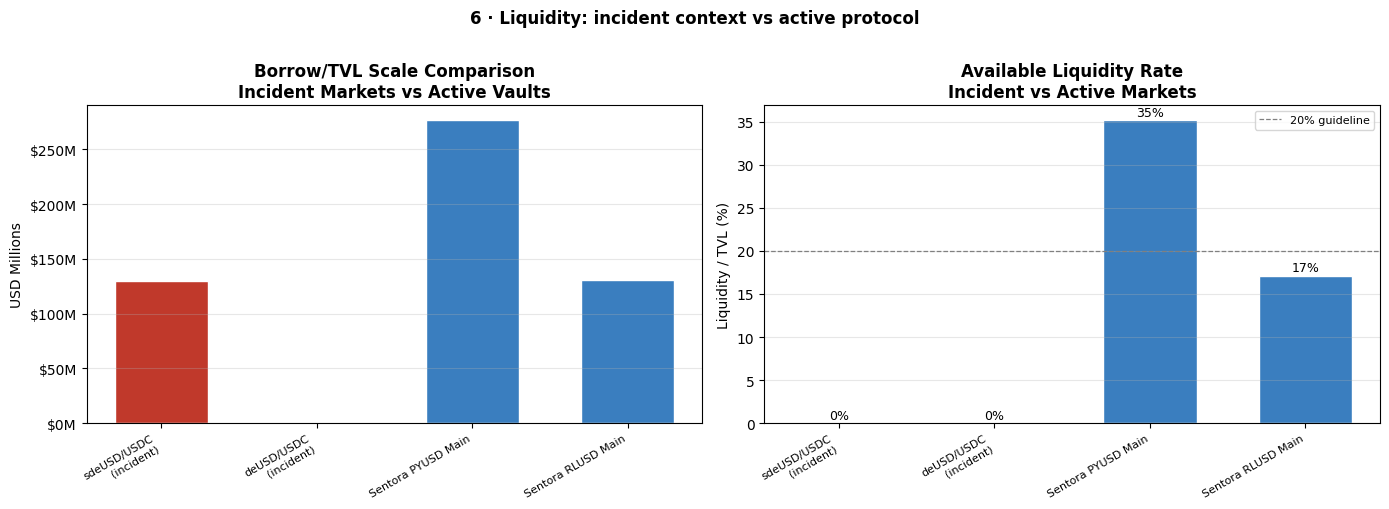

In [21]:
# Liquidity comparison: incident vs healthy markets
top5 = sorted(v2_top, key=lambda v: v.get('totalAssetsUsd',0), reverse=True)[:5]
all_names = ['sdeUSD/USDC\n(incident)', 'deUSD/USDC\n(incident)'] + [v['name'][:20] for v in top5]
all_tvls  = [borrow, 20585] + [v.get('totalAssetsUsd',0) for v in top5]
all_liqs  = [0, 0] + [v.get('liquidityUsd',0) for v in top5]
all_cols  = [C_RED, C_ORANGE] + [C_BLUE]*5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(all_names, [v/1e6 for v in all_tvls], color=all_cols, edgecolor='white', width=0.6)
axes[0].set_ylabel('USD Millions')
axes[0].set_title('Borrow/TVL Scale Comparison\nIncident Markets vs Active Vaults', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
axes[0].set_xticklabels(all_names, rotation=30, ha='right', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

all_liq_pct = [0, 0] + [
    v.get('liquidityUsd',0)/v.get('totalAssetsUsd',1)*100 for v in top5]
axes[1].bar(all_names, all_liq_pct, color=all_cols, edgecolor='white', width=0.6)
for i, p in enumerate(all_liq_pct):
    axes[1].text(i, p+0.5, f'{p:.0f}%', ha='center', fontsize=9)
axes[1].axhline(20, color='gray', linestyle='--', linewidth=0.9, label='20% guideline')
axes[1].set_ylabel('Liquidity / TVL (%)')
axes[1].set_title('Available Liquidity Rate\nIncident vs Active Markets', fontweight='bold')
axes[1].set_xticklabels(all_names, rotation=30, ha='right', fontsize=8)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('6 · Liquidity: incident context vs active protocol', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### The verdict: isolation is real but incomplete

**What isolation protects:**
- The $130M bad debt in sdeUSD/USDC **cannot** automatically reduce the share price of a WETH/USDC vault depositor. Accounting is fully siloed.
- Liquidation shortfalls in one market do not trigger margin calls elsewhere.

**What isolation does NOT protect against:**

| Risk channel | Mechanism | Isolated? |
|---|---|---|
| Accounting contagion | Bad debt in market A -> losses in market B | Yes - fully isolated |
| Vault withdrawal cascade | Panic withdrawal -> vault liquidates across ALL allocated markets | No - shared |
| Oracle/confidence risk | Major Morpho incident -> broad depositor fear | No - shared |
| Reputational risk | '$130M Morpho bad debt' headline -> withdrawals across all vaults | No - shared |

**This incident specifically:**
Because no curator vault allocated to incident markets, the vault-level contagion channel was not activated. This is the best-case isolation scenario. But the $130M bad debt was **completely opaque** to the curator-managed ecosystem — no curator's allocation dashboard showed this risk, which is itself a monitoring gap.

**The key insight for integrators:**
When a curator vault *does* allocate across markets that include stressed assets, depositors face shared liquidity risk even though markets are isolated. A single large redemption wave can drain liquidity from multiple healthy markets simultaneously. Morpho's isolation is an **accounting guarantee**, not a **liquidity guarantee**. Plan monitoring and liquidity buffers accordingly.
